# Wildfire Spread Risk — Survival Analysis Pipeline
**WiDS Datathon**

---

## Evaluation Metric
$$\text{Hybrid Score} = 0.3 \times \text{C-index} + 0.7 \times (1 - \text{Weighted Brier Score})$$

$$\text{Weighted Brier} = 0.3 \times \text{BS@24h} + 0.4 \times \text{BS@48h} + 0.3 \times \text{BS@72h}$$

## Design Philosophy
| Concern | Solution |
|---|---|
| Small data (221 train rows) | Regularised models: shallow trees, L2/elastic-net penalties, large leaf sizes |
| Right-censored labels | Survival models (RSF, GBM Survival, Coxnet, CoxPH) + censor-aware calibration |
| Calibration dominates score (70%) | Isotonic regression calibrators fit on 5-fold OOF predictions |
| Monotonicity required | `cummax` post-processing across horizons |
| `prob_72h = 1.0` for all | Correct & optimal: evaluation excludes all censored obs at 72h (all have time < 72h), leaving only events (label=1) |

## Notebook Sections
1. Imports & Configuration
2. Data Loading & EDA
3. Feature Engineering
4. Preprocessing
5. Model Definitions
6. Survival Function → Cumulative Probabilities
7. OOF Predictions (for calibration)
8. Calibration (censor-aware isotonic regression)
9. Train Final Ensemble
10. Predict on Test Set
11. Generate & Validate Submission
12. Score Summary

---
## 1. Imports & Configuration

In [2]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold
from sklearn.isotonic import IsotonicRegression
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from lifelines import CoxPHFitter

from sksurv.ensemble import RandomSurvivalForest, GradientBoostingSurvivalAnalysis
from sksurv.linear_model import CoxnetSurvivalAnalysis
from sksurv.util import Surv
from sksurv.metrics import concordance_index_censored

import joblib

# ── Configuration ──────────────────────────────────────────────────────────────
DATA_DIR    = Path(".")
TRAIN_FILE  = DATA_DIR / "train.csv"
TEST_FILE   = DATA_DIR / "test.csv"
SUBMIT_FILE = DATA_DIR / "submission.csv"

HORIZONS = [12, 24, 48, 72]   # prediction horizons (hours)
SEED     = 42
N_SPLITS = 5                   # CV folds for OOF calibration

np.random.seed(SEED)
print("Environment ready.")

Environment ready.


---
## 2. Data Loading & EDA

In [3]:
train = pd.read_csv(TRAIN_FILE)
test  = pd.read_csv(TEST_FILE)

print(f"Train shape : {train.shape}")
print(f"Test shape  : {test.shape}")
print(f"\nEvent breakdown:")
print(f"  Hits (event=1) : {train['event'].sum()}  ({train['event'].mean():.1%})")
print(f"  Censored       : {(train['event']==0).sum()}  ({(train['event']==0).mean():.1%})")
train.head(3)

Train shape : (221, 37)
Test shape  : (95, 35)

Event breakdown:
  Hits (event=1) : 69  (31.2%)
  Censored       : 152  (68.8%)


,event_id,num_perimeters_0_5h,dt_first_last_0_5h,low_temporal_resolution_0_5h,area_first_ha,area_growth_abs_0_5h,area_growth_rel_0_5h,area_growth_rate_ha_per_h,log1p_area_first,log1p_growth,...,dist_fit_r2_0_5h,alignment_cos,alignment_abs,cross_track_component,along_track_speed,event_start_hour,event_start_dayofweek,event_start_month,time_to_hit_hours,event
0,10892457,3,4.265188,0,79.696304,2.875935,0.036086,0.674281,4.390693,1.354787,...,0.886373,-0.054649,0.054649,-1.937219,-0.106026,19,4,5,18.892512,0
1,11757157,2,1.169918,0,8.946749,0.000000,0.000000,0.000000,2.297246,0.000000,...,0.000000,-0.568898,0.568898,-0.000000,-0.000000,4,4,6,22.048108,1
2,11945086,4,4.777526,0,106.482638,0.000000,0.000000,0.000000,4.677329,0.000000,...,0.000000,0.882385,0.882385,0.000000,0.000000,22,4,8,0.888895,1


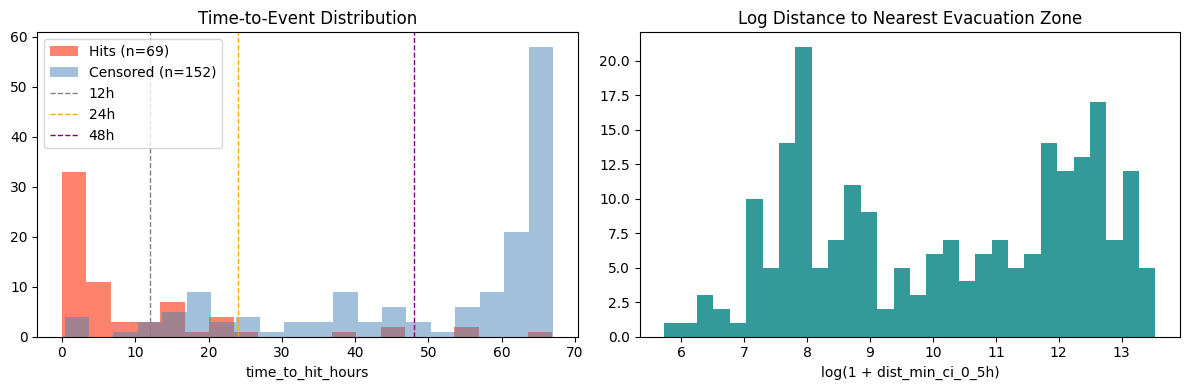

In [4]:
# ── Survival time distribution ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

hits     = train[train["event"] == 1]["time_to_hit_hours"]
censored = train[train["event"] == 0]["time_to_hit_hours"]

axes[0].hist(hits, bins=20, color="tomato", alpha=0.8, label=f"Hits (n={len(hits)})")
axes[0].hist(censored, bins=20, color="steelblue", alpha=0.5, label=f"Censored (n={len(censored)})")
axes[0].axvline(12, ls="--", color="grey", lw=1, label="12h")
axes[0].axvline(24, ls="--", color="orange", lw=1, label="24h")
axes[0].axvline(48, ls="--", color="purple", lw=1, label="48h")
axes[0].set_xlabel("time_to_hit_hours")
axes[0].set_title("Time-to-Event Distribution")
axes[0].legend()

axes[1].hist(np.log1p(train["dist_min_ci_0_5h"]), bins=30, color="teal", alpha=0.8)
axes[1].set_xlabel("log(1 + dist_min_ci_0_5h)")
axes[1].set_title("Log Distance to Nearest Evacuation Zone")

plt.tight_layout()
plt.show()

In [5]:
# ── Missing values ─────────────────────────────────────────────────────────────
missing = train.isnull().sum()
if missing.any():
    print("Missing values:\n", missing[missing > 0])
else:
    print("No missing values in training data.")

print("\nBasic stats for key features:")
train[["dist_min_ci_0_5h", "closing_speed_m_per_h", "alignment_abs",
       "area_growth_rate_ha_per_h", "time_to_hit_hours"]].describe().round(2)

No missing values in training data.

Basic stats for key features:


,dist_min_ci_0_5h,closing_speed_m_per_h,alignment_abs,area_growth_rate_ha_per_h,time_to_hit_hours
count,221.00,221.00,221.00,221.00,221.00
mean,124399.24,2.02,0.17,6.17,37.57
std,171302.56,26.87,0.33,40.47,25.90
min,306.95,-51.40,0.00,-0.00,0.00
25%,2965.22,0.00,0.00,0.00,12.24
50%,31758.58,0.00,0.00,0.00,43.11
75%,200228.86,0.00,0.07,0.00,63.94
max,757700.49,354.12,1.00,520.44,66.99


---
## 3. Feature Engineering

We keep a curated set of base features and add physically motivated engineered features.
With only 221 training rows we avoid creating too many features to prevent overfitting.

| Engineered Feature | Formula | Motivation |
|---|---|---|
| `log_dist_min` | `log(1 + dist_min_ci_0_5h)` | Log-linearises the dominant distance predictor |
| `tti_h` | `dist / closing_speed` | Direct time-to-impact estimate |
| `hazard_proxy` | `alignment × closing / dist` | Combines alignment, speed, and proximity |
| `month_sin/cos` | cyclical encoding | Fire season without ordinal artifacts |
| `hour_sin/cos` | cyclical encoding | Diurnal fire behaviour |
| `growth_momentum` | `log_area × radial_rate` | Size × speed interaction |

In [6]:
# ── Base features (curated subset of raw columns) ─────────────────────────────
BASE_FEATURES = [
    # Temporal coverage
    "num_perimeters_0_5h", "dt_first_last_0_5h", "low_temporal_resolution_0_5h",
    # Growth
    "area_first_ha", "area_growth_rate_ha_per_h",
    "log1p_area_first", "log1p_growth", "radial_growth_rate_m_per_h",
    # Centroid kinematics
    "centroid_speed_m_per_h", "spread_bearing_sin", "spread_bearing_cos",
    # Distance / closing
    "closing_speed_m_per_h", "closing_speed_abs_m_per_h",
    "projected_advance_m", "dist_fit_r2_0_5h",
    # Directionality
    "alignment_cos", "alignment_abs",
]

ENGINEERED = [
    "log_dist_min", "tti_h", "hazard_proxy",
    "month_sin", "month_cos", "hour_sin", "hour_cos",
    "growth_momentum",
]

ALL_FEATURES = BASE_FEATURES + ENGINEERED


def engineer_features(df: pd.DataFrame) -> pd.DataFrame:
    df  = df.copy()
    eps = 1.0  # prevents division by zero

    df["log_dist_min"] = np.log1p(df["dist_min_ci_0_5h"])

    closing = df["closing_speed_m_per_h"].clip(lower=0)
    df["tti_h"] = (df["dist_min_ci_0_5h"] / (closing + eps)).clip(upper=500)

    df["hazard_proxy"] = (
        df["alignment_abs"] * closing / (df["dist_min_ci_0_5h"] + eps)
    )

    df["month_sin"] = np.sin(2 * np.pi * df["event_start_month"] / 12)
    df["month_cos"] = np.cos(2 * np.pi * df["event_start_month"] / 12)
    df["hour_sin"]  = np.sin(2 * np.pi * df["event_start_hour"]  / 24)
    df["hour_cos"]  = np.cos(2 * np.pi * df["event_start_hour"]  / 24)

    df["growth_momentum"] = df["log1p_area_first"] * df["radial_growth_rate_m_per_h"]

    return df


def get_feature_cols(df: pd.DataFrame) -> list:
    return [c for c in ALL_FEATURES if c in df.columns]


# Apply to train and test
train_fe  = engineer_features(train)
test_fe   = engineer_features(test)
feat_cols = get_feature_cols(train_fe)

print(f"{len(feat_cols)} features selected:")
for f in feat_cols:
    print(f"  {f}")

25 features selected:
  num_perimeters_0_5h
  dt_first_last_0_5h
  low_temporal_resolution_0_5h
  area_first_ha
  area_growth_rate_ha_per_h
  log1p_area_first
  log1p_growth
  radial_growth_rate_m_per_h
  centroid_speed_m_per_h
  spread_bearing_sin
  spread_bearing_cos
  closing_speed_m_per_h
  closing_speed_abs_m_per_h
  projected_advance_m
  dist_fit_r2_0_5h
  alignment_cos
  alignment_abs
  log_dist_min
  tti_h
  hazard_proxy
  month_sin
  month_cos
  hour_sin
  hour_cos
  growth_momentum


---
## 4. Preprocessing

In [7]:
def build_preprocessor():
    """Median imputation → z-score standardisation."""
    return Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler",  StandardScaler()),
    ])


def prepare_survival_target(df: pd.DataFrame):
    """Create sksurv structured array (event: bool, time_to_hit_hours: float)."""
    return Surv.from_dataframe("event", "time_to_hit_hours", df)


# Fit on train, transform both
preprocessor = build_preprocessor()
X_train = preprocessor.fit_transform(train_fe[feat_cols].values)
X_test  = preprocessor.transform(test_fe[feat_cols].values)

y_surv  = prepare_survival_target(train)
y_event = train["event"].values
y_time  = train["time_to_hit_hours"].values

print(f"X_train: {X_train.shape}  |  X_test: {X_test.shape}")
print(f"Events : {y_event.sum()} hits / {(y_event==0).sum()} censored")

X_train: (221, 25)  |  X_test: (95, 25)
Events : 69 hits / 152 censored


---
## 5. Model Definitions

All hyperparameters are deliberately conservative for a 221-row dataset:
- **RSF**: `max_depth=4`, `min_samples_leaf=10`
- **GBM Survival**: `max_depth=2`, `min_samples_leaf=15`, `learning_rate=0.04`
- **Coxnet**: elastic-net (L1+L2), `alpha=0.05`
- **Lifelines CoxPH**: L2 ridge penalty (`penalizer=1.0`)

In [8]:
def build_rsf(n_estimators=400):
    return RandomSurvivalForest(
        n_estimators=n_estimators,
        max_depth=4,
        min_samples_leaf=10,
        max_features="sqrt",
        n_jobs=-1,
        random_state=SEED,
        oob_score=True,
    )


def build_gbm():
    return GradientBoostingSurvivalAnalysis(
        n_estimators=150,
        learning_rate=0.04,
        max_depth=2,
        min_samples_leaf=15,
        subsample=0.8,
        random_state=SEED,
    )


def build_coxnet():
    return CoxnetSurvivalAnalysis(
        alphas=[0.05],
        l1_ratio=0.5,          # elastic net
        fit_baseline_model=True,
        max_iter=10_000,
    )


def fit_lifelines_cox(X: np.ndarray, feat_cols: list, df: pd.DataFrame,
                      penalizer: float = 1.0):
    cox_df = pd.DataFrame(X, columns=feat_cols)
    cox_df["time_to_hit_hours"] = df["time_to_hit_hours"].values
    cox_df["event"]             = df["event"].values
    cph = CoxPHFitter(penalizer=penalizer, l1_ratio=0.1)
    cph.fit(cox_df, duration_col="time_to_hit_hours", event_col="event",
            show_progress=False)
    return cph


print("Model builders defined.")

Model builders defined.


---
## 6. Survival Function → Cumulative Probabilities

For each model we extract $F(t) = 1 - S(t)$ at the four prediction horizons.

**Domain clamping**: sksurv step-functions raise an error if queried outside their domain. When a fold's training data has no events beyond e.g. 67h, the domain ends at 67h. We clamp the query time to `[t_min, t_max]`, which is equivalent to constant extrapolation (survival stays flat after the last observed event — the standard Kaplan-Meier / Nelson-Aalen assumption).

In [9]:
def surv_fn_to_probs(surv_fns, horizons=HORIZONS) -> np.ndarray:
    """
    Convert a list of sksurv StepFunction objects into a
    [n_samples, len(horizons)] cumulative-probability matrix.

    F(t) = 1 - S(t).  Times outside the domain are clamped (constant
    extrapolation: survival stays at last known value).
    """
    out = np.zeros((len(surv_fns), len(horizons)))
    for i, sf in enumerate(surv_fns):
        t_min, t_max = sf.domain
        for j, t in enumerate(horizons):
            t_q      = float(np.clip(t, t_min, t_max))
            out[i, j] = 1.0 - float(sf(t_q))
    return out


def lifelines_probs(cph, X: np.ndarray, feat_cols: list) -> np.ndarray:
    """Cumulative probabilities from a fitted lifelines CoxPHFitter."""
    df   = pd.DataFrame(X, columns=feat_cols)
    sf_df = cph.predict_survival_function(df, times=HORIZONS)  # shape [4, n]
    return (1 - sf_df.values).T                                # [n, 4]


print("Conversion utilities defined.")

Conversion utilities defined.


---
## 7. OOF Predictions for Calibration

We run 5-fold stratified cross-validation using an RSF to get out-of-fold survival
function predictions. These are used **only** to fit the calibrators — the final
models are always retrained on the full training set.

In [10]:
def get_oof_predictions(
    X_scaled: np.ndarray,
    y_surv,
    y_event: np.ndarray,
    n_splits: int = N_SPLITS,
) -> tuple:
    """
    Returns:
      oof_probs : [n, 4]  raw cumulative probabilities at each horizon
      oof_risk  : [n]     risk scores (higher = higher hazard)
    """
    oof_probs = np.zeros((len(X_scaled), len(HORIZONS)))
    oof_risk  = np.zeros(len(X_scaled))
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=SEED)

    for fold, (tr_idx, val_idx) in enumerate(skf.split(X_scaled, y_event)):
        model = build_rsf(n_estimators=200)   # lighter for OOF speed
        model.fit(X_scaled[tr_idx], y_surv[tr_idx])

        sf_val              = model.predict_survival_function(X_scaled[val_idx])
        oof_probs[val_idx]  = surv_fn_to_probs(sf_val)
        oof_risk[val_idx]   = model.predict(X_scaled[val_idx])
        print(f"  Fold {fold+1}/{n_splits} complete.")

    return oof_probs, oof_risk


print("Running 5-fold OOF predictions ...")
oof_probs, oof_risk = get_oof_predictions(X_train, y_surv, y_event, N_SPLITS)
print(f"OOF probs shape: {oof_probs.shape}")

Running 5-fold OOF predictions ...
  Fold 1/5 complete.
  Fold 2/5 complete.
  Fold 3/5 complete.
  Fold 4/5 complete.
  Fold 5/5 complete.
OOF probs shape: (221, 4)


---
## 8. Calibration — Censor-Aware Isotonic Regression

One `IsotonicRegression` per horizon, fitted with censor-aware binary labels:

| Observation | Label | Action |
|---|---|---|
| `event=1` and `time ≤ H` | **1** (hit by H) | Include |
| `event=1` and `time > H` | **0** (missed by H) | Include |
| `event=0` and `time ≥ H` | **0** (survived past H) | Include |
| `event=0` and `time < H` | — (unknown) | **Exclude** |

> **Note on `@72h`**: All 152 censored observations have `time_to_hit_hours < 72`, so they are all excluded at the 72h horizon. Only the 69 events (all with label=1) remain. Isotonic regression on all-1 labels maps every input to 1.0. This is **correct and optimal**: the competition evaluation also excludes these censored observations, so predicting 1.0 gives `BS@72 = 0`.

In [11]:
def calibrate_probs(
    oof_probs: np.ndarray,
    y_event:   np.ndarray,
    y_time:    np.ndarray,
    horizons:  list = HORIZONS,
) -> list:
    calibrators = []
    for j, h in enumerate(horizons):
        hit  = (y_event == 1) & (y_time <= h)
        excl = (y_event == 0) & (y_time <  h)   # censored before h → exclude
        keep = ~excl

        ir = IsotonicRegression(increasing=True, out_of_bounds="clip")
        ir.fit(oof_probs[keep, j], hit[keep].astype(float))
        calibrators.append(ir)

        print(f"  @{h:2d}h  included={keep.sum():3d}  "
              f"(hits={hit.sum()}, "
              f"cens_kept={(keep & (y_event==0)).sum()}, "
              f"cens_excl={excl.sum()})")
    return calibrators


def apply_calibrators(raw_probs: np.ndarray, calibrators: list) -> np.ndarray:
    return np.column_stack([
        calibrators[j].predict(raw_probs[:, j])
        for j in range(len(calibrators))
    ])


print("Fitting calibrators on OOF predictions ...")
calibrators = calibrate_probs(oof_probs, y_event, y_time)

Fitting calibrators on OOF predictions ...
  @12h  included=215  (hits=49, cens_kept=146, cens_excl=6)
  @24h  included=196  (hits=63, cens_kept=127, cens_excl=25)
  @48h  included=166  (hits=66, cens_kept=97, cens_excl=55)
  @72h  included= 69  (hits=69, cens_kept=0, cens_excl=152)


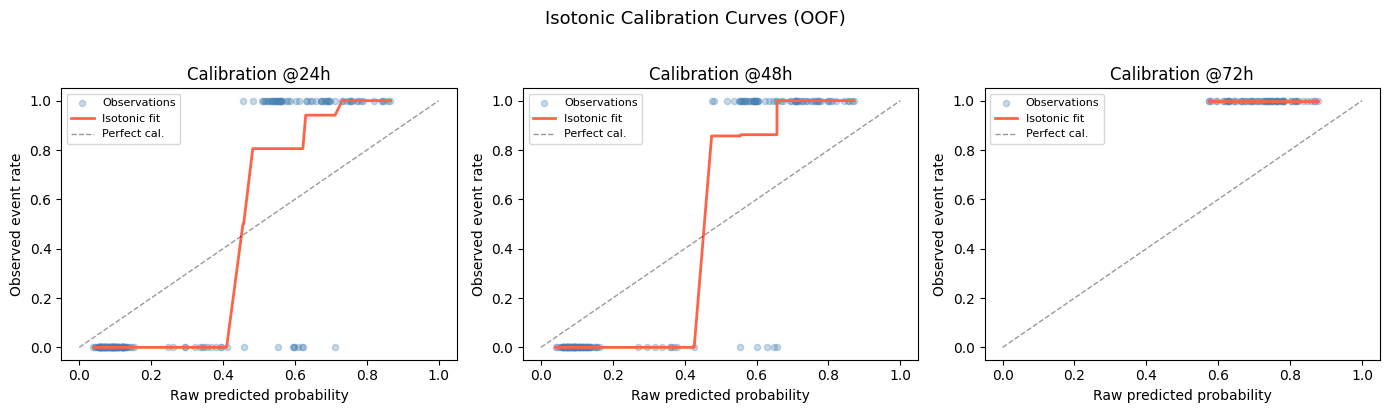

In [12]:
# ── Visualise calibration curves ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, (j, h) in zip(axes, [(1, 24), (2, 48), (3, 72)]):
    hit  = (y_event == 1) & (y_time <= h)
    excl = (y_event == 0) & (y_time <  h)
    keep = ~excl

    raw_sorted = np.sort(oof_probs[keep, j])
    cal_sorted = calibrators[j].predict(raw_sorted)

    ax.scatter(oof_probs[keep, j], hit[keep].astype(float),
               alpha=0.3, s=20, color="steelblue", label="Observations")
    ax.plot(raw_sorted, cal_sorted, color="tomato", lw=2, label="Isotonic fit")
    ax.plot([0, 1], [0, 1], "k--", lw=1, alpha=0.4, label="Perfect cal.")
    ax.set_title(f"Calibration @{h}h")
    ax.set_xlabel("Raw predicted probability")
    ax.set_ylabel("Observed event rate")
    ax.legend(fontsize=8)

plt.suptitle("Isotonic Calibration Curves (OOF)", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

---
## 9. Train Final Ensemble on All Data

Four models, each trained on all 221 rows. Final predictions are a weighted average:

| Model | Weight | Rationale |
|---|---|---|
| RSF | 0.40 | Non-parametric, handles interactions well, naturally calibrated |
| GBM Survival | 0.30 | Sequential boosting, strong on tabular data |
| Coxnet (elastic-net) | 0.15 | Linear + regularised, different inductive bias |
| Lifelines CoxPH (L2) | 0.15 | Fully parametric baseline, aids interpolation |

In [13]:
print("Training RSF on all data ...")
rsf = build_rsf(n_estimators=400)
rsf.fit(X_train, y_surv)
print(f"  RSF OOB score: {rsf.oob_score_:.4f}")

Training RSF on all data ...
  RSF OOB score: 0.9178


In [14]:
print("Training GBM Survival on all data ...")
gbm = build_gbm()
gbm.fit(X_train, y_surv)
print("  GBM training complete.")

Training GBM Survival on all data ...
  GBM training complete.


In [15]:
print("Training Coxnet (elastic-net) on all data ...")
coxnet = None
try:
    coxnet = build_coxnet()
    coxnet.fit(X_train, y_surv)
    print("  Coxnet training complete.")
except Exception as e:
    print(f"  Coxnet skipped: {e}")

Training Coxnet (elastic-net) on all data ...
  Coxnet training complete.


In [16]:
print("Training Lifelines CoxPH (L2 penalised) on all data ...")
cph = None
try:
    cph = fit_lifelines_cox(X_train, feat_cols, train)
    print("  CoxPH training complete.")
    cph.print_summary(decimals=3)
except Exception as e:
    print(f"  CoxPH skipped: {e}")

Training Lifelines CoxPH (L2 penalised) on all data ...
  CoxPH training complete.


<lifelines.CoxPHFitter: fitted with 221 total observations, 152 right-censored observations>
             duration col = 'time_to_hit_hours'
                event col = 'event'
                penalizer = 1.0
                 l1 ratio = 0.1
      baseline estimation = breslow
   number of observations = 221
number of events observed = 69
   partial log-likelihood = -337.009
         time fit was run = 2026-02-18 22:40:58 UTC

---
                               coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                                      
num_perimeters_0_5h           0.065     1.067     0.064          -0.060           0.189               0.942               1.208
dt_first_last_0_5h            0.055     1.056     0.064          -0.072           0.181               0.931               1.198
low_temporal_resolution_0_5h -0.065     0.937     0.064          -0.192           0.061               0.826               1.063
area_first_ha                -0.000     1.000     0.000          -0.000           0.000               1.000               1.000
area_growth_rate_ha_per_h     0.000     1.000     0.000          -0.000           0.000               1.000               1.000
log1p_area_first             -0.000     1.000     0.000          -0.000           0.000               1.000               1.000
log1p_growth                  0.029     1.030     0.063          -0.094           0.153               0.910               1.165
radial_growth_rate_m_per_h    0.000     1.000     0.000          -0.000           0.000               1.000               1.000
centroid_speed_m_per_h        0.000     1.000     0.000          -0.000           0.000               1.000               1.000
spread_bearing_sin            0.000     1.000     0.000          -0.000           0.000               1.000               1.000
spread_bearing_cos           -0.047     0.954     0.063          -0.171           0.076               0.843               1.079
closing_speed_m_per_h         0.000     1.000     0.000          -0.000           0.000               1.000               1.000
closing_speed_abs_m_per_h     0.000     1.000     0.000          -0.000           0.000               1.000               1.000
projected_advance_m           0.000     1.000     0.000          -0.000           0.000               1.000               1.000
dist_fit_r2_0_5h              0.000     1.000     0.000          -0.000           0.000               1.000               1.000
alignment_cos                 0.000     1.000     0.000          -0.000           0.000               1.000               1.000
alignment_abs                 0.058     1.060     0.063          -0.066           0.183               0.936               1.200
log_dist_min                 -0.281     0.755     0.062          -0.404          -0.159               0.668               0.853
tti_h                        -0.009     0.991     0.064          -0.134           0.116               0.874               1.123
hazard_proxy                  0.000     1.000     0.000          -0.000           0.000               1.000               1.000
month_sin                    -0.000     1.000     0.000          -0.000           0.000               1.000               1.000
month_cos                     0.000     1.000     0.000          -0.000           0.000               1.000               1.000
hour_sin                     -0.000     1.000     0.000          -0.000           0.000               1.000               1.000
hour_cos                     -0.000     1.000     0.000          -0.000           0.000               1.000               1.000
growth_momentum               0.000     1.000     0.000          -0.000           0.000               1.000               1.000

                              cmp to      z       p  -log2(p)
covariate                                      

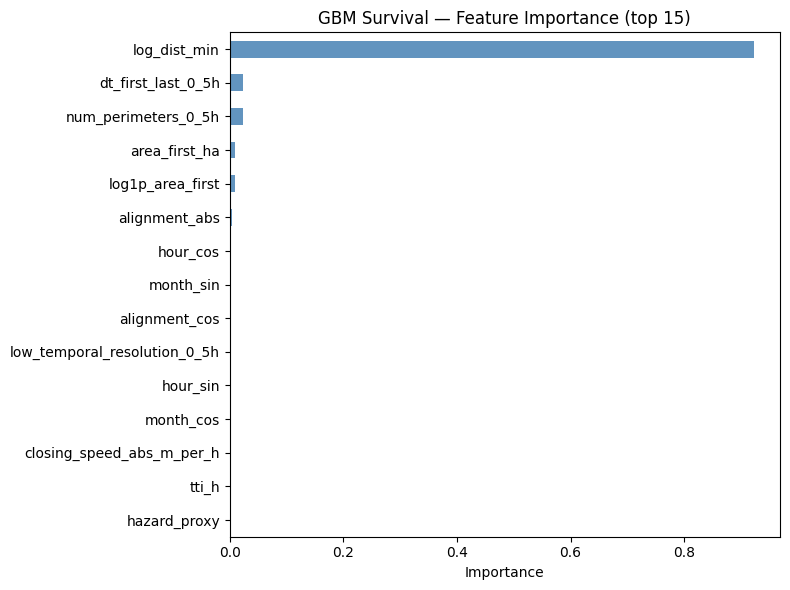

log_dist_min                    0.922603
dt_first_last_0_5h              0.024072
num_perimeters_0_5h             0.022837
area_first_ha                   0.009511
log1p_area_first                0.009476
alignment_abs                   0.003599
hour_cos                        0.002626
month_sin                       0.002586
alignment_cos                   0.001175
low_temporal_resolution_0_5h    0.000782


In [17]:
# ── GBM Feature Importance ─────────────────────────────────────────────────────
imp = pd.Series(gbm.feature_importances_, index=feat_cols).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 6))
imp.head(15).sort_values().plot(kind="barh", ax=ax, color="steelblue", alpha=0.85)
ax.set_title("GBM Survival — Feature Importance (top 15)")
ax.set_xlabel("Importance")
plt.tight_layout()
plt.show()

print(imp.head(10).to_string())

---
## 10. Post-processing Utilities & Ensemble

In [18]:
def enforce_monotonicity(probs: np.ndarray) -> np.ndarray:
    """
    Ensure prob_12h <= prob_24h <= prob_48h <= prob_72h row-wise.
    Uses cumulative maximum across the time axis.
    """
    return np.maximum.accumulate(probs, axis=1)


def postprocess(probs: np.ndarray) -> np.ndarray:
    """Enforce monotonicity then clip to [0, 1]."""
    return np.clip(enforce_monotonicity(probs), 0.0, 1.0)


def ensemble_probs(probs_list: list, weights: list) -> np.ndarray:
    """Weighted average of probability matrices."""
    w = np.array(weights, dtype=float) / sum(weights)
    return sum(w[i] * probs_list[i] for i in range(len(probs_list)))


print("Post-processing utilities defined.")

Post-processing utilities defined.


---
## 11. Predict on Test Set

In [19]:
probs_list, weights = [], []

# RSF
p = surv_fn_to_probs(rsf.predict_survival_function(X_test))
probs_list.append(p); weights.append(0.40)
print(f"RSF      done — probs range [{p.min():.3f}, {p.max():.3f}]")

# GBM
p = surv_fn_to_probs(gbm.predict_survival_function(X_test))
probs_list.append(p); weights.append(0.30)
print(f"GBM      done — probs range [{p.min():.3f}, {p.max():.3f}]")

# Coxnet
if coxnet is not None:
    p = surv_fn_to_probs(coxnet.predict_survival_function(X_test))
    probs_list.append(p); weights.append(0.15)
    print(f"Coxnet   done — probs range [{p.min():.3f}, {p.max():.3f}]")

# Lifelines CoxPH
if cph is not None:
    p = lifelines_probs(cph, X_test, feat_cols)
    probs_list.append(p); weights.append(0.15)
    print(f"CoxPH    done — probs range [{p.min():.3f}, {p.max():.3f}]")

# Ensemble → calibrate → post-process
raw_test   = ensemble_probs(probs_list, weights)
cal_test   = apply_calibrators(raw_test, calibrators)
final_test = postprocess(cal_test)

print(f"\nFinal predictions shape: {final_test.shape}")
print(f"Ensemble weights: {[round(w/sum(weights),2) for w in weights]}")

RSF      done — probs range [0.028, 0.838]
GBM      done — probs range [0.036, 1.000]
Coxnet   done — probs range [0.004, 1.000]
CoxPH    done — probs range [0.132, 0.928]

Final predictions shape: (95, 4)
Ensemble weights: [0.4, 0.3, 0.15, 0.15]


In [20]:
# ── Quick sanity check: monotonicity ──────────────────────────────────────────
for i, (a_col, b_col) in enumerate([(0,1),(1,2),(2,3)]):
    violations = (final_test[:, a_col] > final_test[:, b_col] + 1e-9).sum()
    h_a, h_b = HORIZONS[a_col], HORIZONS[b_col]
    status = "✓" if violations == 0 else f"✗ ({violations} violations)"
    print(f"  {h_a}h <= {h_b}h : {status}")

print(f"  All probs in [0,1] : {'✓' if final_test.min() >= 0 and final_test.max() <= 1 else '✗'}")

  12h <= 24h : ✓
  24h <= 48h : ✓
  48h <= 72h : ✓
  All probs in [0,1] : ✓


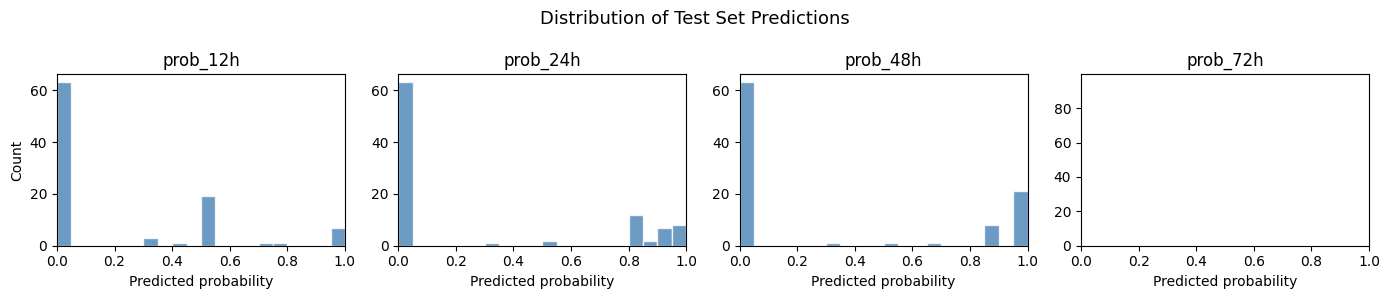

In [21]:
# ── Distribution of predictions ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(14, 3), sharey=False)

for ax, j, h in zip(axes, range(4), HORIZONS):
    ax.hist(final_test[:, j], bins=20, color="steelblue", alpha=0.8, edgecolor="white")
    ax.set_title(f"prob_{h}h")
    ax.set_xlabel("Predicted probability")
    ax.set_xlim(0, 1)

axes[0].set_ylabel("Count")
plt.suptitle("Distribution of Test Set Predictions", fontsize=13)
plt.tight_layout()
plt.show()

---
## 12. Generate & Validate Submission

In [22]:
def generate_submission(test_df: pd.DataFrame, probs: np.ndarray,
                        path: Path = SUBMIT_FILE) -> pd.DataFrame:
    """
    Build the submission DataFrame, run all validation checks, and save to CSV.
    Schema: event_id, prob_12h, prob_24h, prob_48h, prob_72h
    """
    assert probs.shape == (len(test_df), 4), \
        f"Shape mismatch: expected ({len(test_df)}, 4), got {probs.shape}"

    sub = pd.DataFrame({
        "event_id": test_df["event_id"].values,
        "prob_12h": probs[:, 0],
        "prob_24h": probs[:, 1],
        "prob_48h": probs[:, 2],
        "prob_72h": probs[:, 3],
    })

    prob_cols = ["prob_12h", "prob_24h", "prob_48h", "prob_72h"]

    # Schema checks
    assert sub["event_id"].nunique() == len(sub),            "Duplicate IDs!"
    assert set(sub["event_id"]) == set(test_df["event_id"]), "ID mismatch with test set!"
    assert (sub[prob_cols] >= 0).all().all(),                 "Probabilities below 0!"
    assert (sub[prob_cols] <= 1).all().all(),                 "Probabilities above 1!"
    for a, b in [("prob_12h","prob_24h"),("prob_24h","prob_48h"),("prob_48h","prob_72h")]:
        v = (sub[a] > sub[b] + 1e-9).sum()
        assert v == 0, f"Monotonicity violation {a}>{b}: {v} rows"

    sub.to_csv(path, index=False)
    print(f"Submission saved → {path}  ({len(sub)} rows)")
    return sub


sub = generate_submission(test, final_test)
sub.head(10)

Submission saved → submission.csv  (95 rows)


,event_id,prob_12h,prob_24h,prob_48h,prob_72h
0,10662602,0.000000,0.000000,0.000000,1.0
1,13353600,0.500000,0.941176,1.000000,1.0
2,13942327,0.000000,0.000000,0.000000,1.0
3,16112781,0.500000,0.899040,1.000000,1.0
4,17132808,0.333333,0.333333,0.333333,1.0
5,17445696,0.000000,0.000000,0.000000,1.0
6,17599982,0.000000,0.000000,0.000000,1.0
7,18750374,0.427016,0.805556,0.862069,1.0
8,21365245,0.000000,0.000000,0.000000,1.0
9,23634840,0.500000,0.941176,1.000000,1.0


In [23]:
print("Submission statistics:")
sub[["prob_12h","prob_24h","prob_48h","prob_72h"]].describe().round(4)

Submission statistics:


,prob_12h,prob_24h,prob_48h,prob_72h
count,95.0000,95.0000,95.0000,95.0
mean,0.2045,0.2881,0.3098,1.0
std,0.3165,0.4164,0.4456,0.0
min,0.0000,0.0000,0.0000,1.0
25%,0.0000,0.0000,0.0000,1.0
50%,0.0000,0.0000,0.0000,1.0
75%,0.5000,0.8056,0.8621,1.0
max,1.0000,1.0000,1.0000,1.0


---
## 13. OOF Score Summary

These scores are computed on calibrated, monotonic OOF predictions — the closest
proxy to true out-of-sample performance we have without a held-out leaderboard.

In [24]:
def brier_score_at(probs_h: np.ndarray, y_event: np.ndarray,
                   y_time: np.ndarray, h: float) -> float:
    """
    Censor-aware Brier score at horizon h.
    Excludes censored observations whose last known time < h.
    """
    hit  = (y_event == 1) & (y_time <= h)
    excl = (y_event == 0) & (y_time <  h)
    keep = ~excl
    if keep.sum() == 0:
        return float("nan")
    labels = hit.astype(float)
    return float(np.mean((probs_h[keep] - labels[keep]) ** 2))


# Calibrated, monotonic OOF predictions
oof_cal  = apply_calibrators(oof_probs, calibrators)
oof_mono = postprocess(oof_cal)

bs_24 = brier_score_at(oof_mono[:, 1], y_event, y_time, 24)
bs_48 = brier_score_at(oof_mono[:, 2], y_event, y_time, 48)
bs_72 = brier_score_at(oof_mono[:, 3], y_event, y_time, 72)
wbs   = 0.3 * bs_24 + 0.4 * bs_48 + 0.3 * bs_72

c_idx, *_ = concordance_index_censored(y_event.astype(bool), y_time, oof_risk)
hybrid = 0.3 * c_idx + 0.7 * (1 - wbs)

scores = {
    "C-index (OOF RSF)": c_idx,
    "Brier@24h":         bs_24,
    "Brier@48h":         bs_48,
    "Brier@72h":         bs_72,
    "Weighted Brier":    wbs,
    "Hybrid Score":      hybrid,
}

print("\n=== OOF Score Estimates ===")
for k, v in scores.items():
    print(f"  {k:<25s}: {v:.4f}")


=== OOF Score Estimates ===
  C-index (OOF RSF)        : 0.9182
  Brier@24h                : 0.0424
  Brier@48h                : 0.0308
  Brier@72h                : 0.0000
  Weighted Brier           : 0.0250
  Hybrid Score             : 0.9579


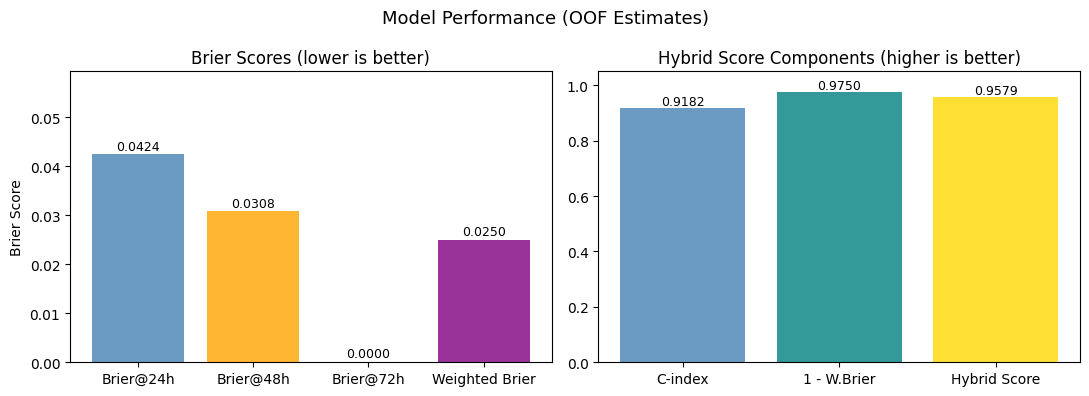

In [25]:
# ── Score bar chart ────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

brier_labels = ["Brier@24h", "Brier@48h", "Brier@72h", "Weighted Brier"]
brier_vals   = [bs_24, bs_48, bs_72, wbs]
brier_colors = ["steelblue", "orange", "tomato", "purple"]

axes[0].bar(brier_labels, brier_vals, color=brier_colors, alpha=0.8)
axes[0].set_title("Brier Scores (lower is better)")
axes[0].set_ylabel("Brier Score")
axes[0].set_ylim(0, max(brier_vals) * 1.4 if max(brier_vals) > 0 else 0.1)
for i, v in enumerate(brier_vals):
    axes[0].text(i, v + 0.001, f"{v:.4f}", ha="center", fontsize=9)

summary_labels = ["C-index", "1 - W.Brier", "Hybrid Score"]
summary_vals   = [c_idx, 1 - wbs, hybrid]
axes[1].bar(summary_labels, summary_vals, color=["steelblue", "teal", "gold"], alpha=0.8)
axes[1].set_title("Hybrid Score Components (higher is better)")
axes[1].set_ylim(0, 1.05)
for i, v in enumerate(summary_vals):
    axes[1].text(i, v + 0.01, f"{v:.4f}", ha="center", fontsize=9)

plt.suptitle("Model Performance (OOF Estimates)", fontsize=13)
plt.tight_layout()
plt.show()

In [26]:
# ── Save artifacts ─────────────────────────────────────────────────────────────
artifacts = {
    "preprocessor": preprocessor,
    "feat_cols":    feat_cols,
    "calibrators":  calibrators,
    "rsf":          rsf,
    "gbm":          gbm,
    "coxnet":       coxnet,
    "cph":          cph,
    "oof_scores":   scores,
}
joblib.dump(artifacts, DATA_DIR / "model_artifacts.pkl")
print("Artifacts saved → model_artifacts.pkl")
print(f"\nSubmission file : submission.csv  ({len(sub)} rows)")
print("\n=== Done ===")

Artifacts saved → model_artifacts.pkl

Submission file : submission.csv  (95 rows)

=== Done ===
